<a href="https://colab.research.google.com/github/zeeshan3106/Machine-Learning/blob/main/Density%20Based%20Clustering%20(DBSCAN)%20on%20real_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [296]:
import pandas as pd
data = pd.read_csv("realestate_data_southcarolina_2025.csv")
data1 = pd.read_csv("city_lifestyle_dataset.csv")
# data = data.drop(['city_name','country','internet_penetration','avg_rent','public_transport_score','air_quality_index','happiness_score','green_space_ratio'],axis = 1)
data = data[['listPrice','year_built','sqft']]
data = data.dropna(how="any")
data.info()
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
data = pd.DataFrame(scale.fit_transform(data),columns=data.columns)

X = data.iloc[:,0:2].values

data


<class 'pandas.core.frame.DataFrame'>
Index: 3317 entries, 0 to 5000
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   listPrice   3317 non-null   float64
 1   year_built  3317 non-null   float64
 2   sqft        3317 non-null   float64
dtypes: float64(3)
memory usage: 103.7 KB


,listPrice,year_built,sqft
0,-0.362709,0.424059,-0.630854
1,-0.452008,-0.125686,-0.887400
2,-0.239922,-0.190362,0.068427
3,-0.496658,-0.481403,-0.771568
4,0.201105,0.003666,-0.376882
...,...,...,...
3312,0.111806,-0.643093,0.597822
3313,-0.228648,1.006142,-0.503010
3314,0.262387,0.650424,1.418083
3315,-0.407247,-0.546079,-0.753550


In [297]:
from sklearn.cluster import DBSCAN
db = DBSCAN(
    eps=1.5,
    min_samples=2
)
training = db.fit_predict(X)
db.labels_





array([0, 0, 0, ..., 0, 0, 0])

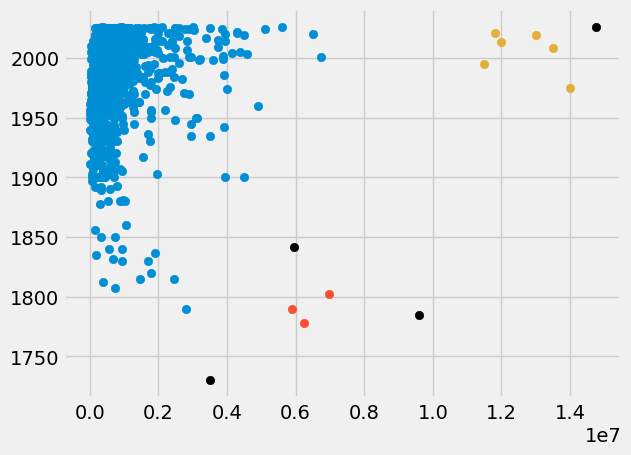

In [298]:
# Grouping exactly your way for the main clusters found in your array:
X= scale.inverse_transform(data)

plt.scatter(X[training==-1, 0], X[training==-1, 1], color='black', label='Noise')
plt.scatter(X[training==0, 0],  X[training==0, 1],  label='Cluster 0')
plt.scatter(X[training==1, 0],  X[training==1, 1],  label='Cluster 1')
plt.scatter(X[training==2, 0],  X[training==2, 1],  label='Cluster 2')
plt.scatter(X[training==5, 0],  X[training==5, 1],  label='Cluster 5')
plt.scatter(X[training==7, 0],  X[training==7, 1],  label='Cluster 7')
plt.scatter(X[training==8, 0],  X[training==8, 1],  label='Cluster 8')



In [310]:
X= scale.inverse_transform(data)

pd.DataFrame(X[training== 2]).iloc[:,:]


,0,1,2
0,11995000.0,2013.0,6540.0
1,14000000.0,1975.0,5106.0
2,11499000.0,1995.0,8560.0
3,13500000.0,2008.0,6740.0
4,11800000.0,2021.0,6755.0
5,12995000.0,2019.0,6881.0
